In [1]:
import sys
sys.path.append('../src')

import torch
import os
from model import UNet
from utils import *
from datamodule import Normalizer

In [8]:
# Test how different hyperparameters affect model size and inference time
import time

depths = [3, 4, 5, 6]
channels = [16, 32, 64]
results = {}
for depth in depths:
    for channel in channels:
        model = UNet(in_channels=1, out_channels=4, depth=depth, base_filters=channel)
        num_params = sum(p.numel() for p in model.parameters())
        print(f'Depth: {depth}, Base Channels: {channel}, Number of Parameters: {num_params}')
        # Measure inference time (a few times and take average for more accuracy)
        input_tensor = torch.randn(1, 1, 256, 256)  # Example input
        start_time = time.time()
        with torch.no_grad():
            for _ in range(50):
                _ = model(input_tensor)
        end_time = time.time()
        inference_time = (end_time - start_time) / 50  # Average time per inference
        
        results[(depth, channel)] = (num_params, inference_time)
        
# Print results in a table format sorted by
print(f'{"Depth":<10} {"Base Channels":<15} {"Num Params":<15} {"Inference Time (s)":<20}')
for (depth, channel), (num_params, inference_time) in results.items():
    print(f'{depth:<10} {channel:<15} {num_params:<15} {inference_time:<20.4f}')

Depth: 3, Base Channels: 16, Number of Parameters: 483304
Depth: 3, Base Channels: 32, Number of Parameters: 1928040
Depth: 3, Base Channels: 64, Number of Parameters: 7702120
Depth: 4, Base Channels: 16, Number of Parameters: 1943912
Depth: 4, Base Channels: 32, Number of Parameters: 7765608
Depth: 4, Base Channels: 64, Number of Parameters: 31042664
Depth: 5, Base Channels: 16, Number of Parameters: 7781480
Depth: 5, Base Channels: 32, Number of Parameters: 31106152
Depth: 5, Base Channels: 64, Number of Parameters: 124385384
Depth: 6, Base Channels: 16, Number of Parameters: 31122024
Depth: 6, Base Channels: 32, Number of Parameters: 124448872
Depth: 6, Base Channels: 64, Number of Parameters: 497717352
Depth      Base Channels   Num Params      Inference Time (s)  
3          16              483304          0.0385              
3          32              1928040         0.0878              
3          64              7702120         0.1900              
4          16              1

In [7]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [8]:
# experiment_dir = '../mlruns/790155756705826000/aaf9a37d4dfb4a04be7c4a1c945594cc'
# # Load configuration
# 
# import os
# 
# def load_config(experiment_dir):
#     config_dir = os.path.join(experiment_dir, 'params')
#     config = {}
#     for param_file in os.listdir(config_dir):
#         with open(os.path.join(config_dir, param_file), 'r') as f:
#             value = f.read().strip()
#             key = param_file    # no extension
#             # Try to convert to int or float if possible
#             try:
#                 value = int(value)
#             except ValueError:
#                 try:
#                     value = float(value)
#                 except ValueError:
#                     pass
#             config[key] = value
#             
#     return config
# 
# config = load_config(experiment_dir)
# config

In [10]:
# Load model weights
# model_dir = os.path.join(experiment_dir, 'checkpoints')
# checkpoint_file = os.listdir(model_dir)[-1]  # Get the latest checkpoint
model_dir = '../working/checkpoints'
checkpoint_file = 'epoch=79-step=5360.ckpt'
model = UNet.load_from_checkpoint(os.path.join(model_dir, checkpoint_file))

In [11]:
model.to(device)
model.eval()

UNet(
  (encoders): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (2): Sequential(
      

In [12]:
# Load sample data
import numpy as np

data = np.load('../data/mixer_256.npz')
inputs, outputs = data['inputs'], data['outputs']
print(f'Inputs shape: {inputs.shape}, Outputs shape: {outputs.shape}')

Inputs shape: (661, 1, 256, 256), Outputs shape: (661, 4, 256, 256)


In [14]:
# Load normalizer
normalizer_path = os.path.join('../working/checkpoints/normalizer.npz')
normalizer = Normalizer.load(normalizer_path)
normalizer

In [15]:
example_input = inputs[0:1]  # Take the first sample
example_output = outputs[0:1]
output = model(torch.tensor(example_input, dtype=torch.float32).to(device))
output = normalizer.inverse_transform(output.cpu().detach())
output[0, :3, :, :]

tensor([[[-2.6214e-04, -7.5270e-04, -1.3528e-03,  ...,  2.3313e-04,
          -1.0557e-03, -3.4329e-03],
         [ 2.2194e-04, -1.1156e-04, -4.1967e-04,  ..., -1.6637e-03,
          -2.7422e-03, -3.2199e-03],
         [ 9.1647e-04,  6.4872e-04,  3.6891e-04,  ..., -1.4542e-03,
          -2.0590e-03, -1.7900e-03],
         ...,
         [-5.2517e-04, -5.5196e-04, -3.5804e-04,  ...,  5.7973e-04,
           8.5000e-04,  9.5291e-04],
         [-4.1630e-04, -1.0823e-03, -1.2578e-03,  ...,  8.2199e-04,
           6.8117e-04,  7.7352e-04],
         [-1.4107e-03, -1.3996e-03, -1.2520e-03,  ...,  1.2784e-03,
           1.0037e-03,  6.3861e-04]],

        [[-6.4197e-04, -1.0996e-03, -1.2478e-03,  ...,  2.9248e-03,
           3.0068e-03,  4.7644e-04],
         [-6.3579e-04, -9.8993e-04, -1.0296e-03,  ..., -3.6279e-04,
          -3.9109e-04, -1.9430e-03],
         [-4.9945e-04, -7.4103e-04, -6.3866e-04,  ..., -4.8235e-05,
           1.4742e-04, -7.6594e-04],
         ...,
         [ 2.0595e-04,  1

In [16]:
coords_array = load_coordinates('../data/coordinates_256.csv')
coords_array

array([[2.5000e-04, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       [7.5000e-04, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       [1.2500e-03, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       ...,
       [1.2675e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10],
       [1.2725e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10],
       [1.2775e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10]], shape=(65536, 4))

In [18]:
example_output

array([[[[ 4.82466151e-08,  5.72843854e-07,  1.33416551e-06, ...,
           1.77509431e-08,  1.13293228e-08,  3.35201071e-09],
         [ 1.76890857e-07,  1.41794100e-06,  2.94590799e-06, ...,
           2.14119053e-08,  1.37575312e-08,  3.94734948e-09],
         [ 2.59193384e-07,  1.82720641e-06,  3.50926950e-06, ...,
           2.00092066e-08,  1.28641629e-08,  3.69561404e-09],
         ...,
         [ 1.19945181e-07,  5.82766569e-07,  8.36976071e-07, ...,
          -9.44070726e-05, -3.73720479e-05, -2.54786178e-06],
         [ 2.24721281e-07,  1.34627126e-06,  2.35466956e-06, ...,
          -5.78444427e-05, -2.02942990e-05, -1.19767511e-06],
         [ 1.44943595e-07,  8.86683311e-07,  1.51631495e-06, ...,
          -1.72968423e-05, -2.79062254e-06,  1.15406328e-06]],

        [[-4.51213745e-08, -1.48307672e-07, -1.82641574e-07, ...,
          -3.81718141e-09, -4.06557396e-09, -3.45057795e-09],
         [-5.86570081e-07, -1.31808719e-06, -1.51760252e-06, ...,
          -1.30811081e

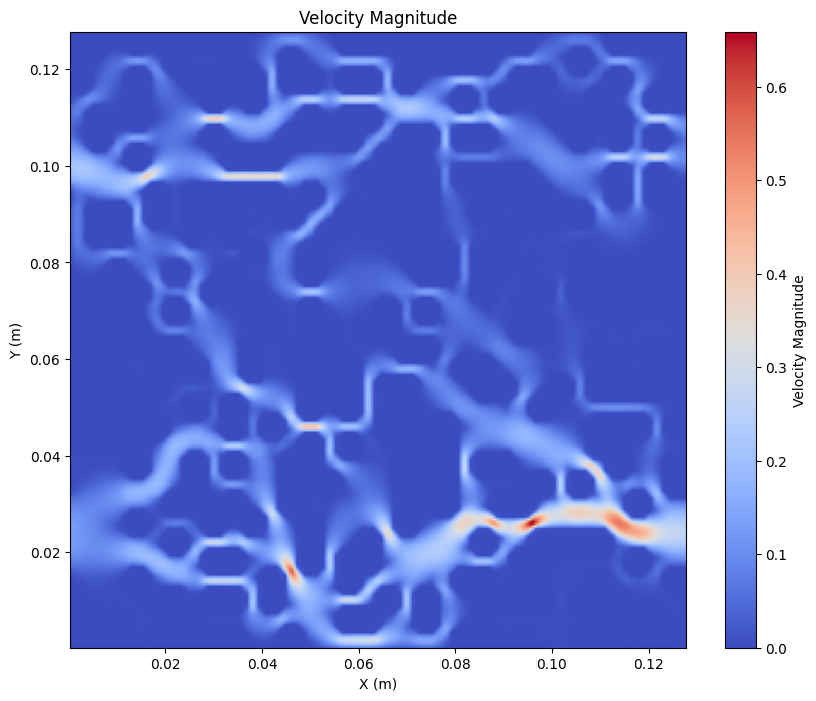

In [17]:
plot_velocity_magnitude(output[0], coords_array)

In [ ]:
# Create a csv file from input and output
def save_to_csv(input_array, output_array, of_output_array, coords_array, filename):
    import pandas as pd

    data = {
        'x': coords_array[:, 0],
        'y': coords_array[:, 1],
        'z': coords_array[:, 2],
        'Ux': output_array[0, 0, :, :].flatten(),
        'Uy': output_array[0, 1, :, :].flatten(),
        'Uz': output_array[0, 2, :, :].flatten(),
        'p': output_array[0, 3, :, :].flatten(),
        'lambda': input_array[0, 0, :, :].flatten(),
        'Ux_OF': of_output_array[:, 0],
    }

    df = pd.DataFrame(data)
    df.to_csv(filename, index=False)
    
save_to_csv(example_input, output.numpy(), coords_array, 'model_output.csv')